# AI-Driven Educational Quiz Platform Generator

This  system can transforms user-specified subjects and knowledge points into a fully functional online quiz platform. Given a topic (e.g., "Python Basics: variables, loops, functions"), the system automatically generates a Flask API with question bank management, random quiz generation, auto-scoring, and grade statistics — along with an interactive frontend featuring quiz pages, result analysis, wrong-answer review, and an AI-generated knowledge mind map image.

The system follows the AI-DLC Methodology.

## Setup & Environment
Load environment, import utilities, initialize LLM client for the Quiz Platform Generator.

In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

# Ensure required dependency for Quiz Platform utils is available
try:
    from PIL import Image  # noqa: F401
    print("✅ Pillow already installed")
except Exception:
    print("Installing Pillow...")
    %pip install pillow
    
# Ensure local imports work
from utils import load_environment, get_completion, get_image_generation_completion

# Load environment variables and set up the LLM client
load_environment()
client, model_name, api_provider = None, None, None
try:
    from utils import setup_llm_client, clean_llm_output, recommended_models_table
    client, model_name, api_provider = setup_llm_client("openai/gpt-5.2")
    print(f"✅ LLM Client initialized: {api_provider} - {model_name}")
except Exception as e:
    print(f"❌ Error initializing LLM client: {e}")

✅ Pillow already installed
✅ LLM Client configured: Using 'apifree' with model 'openai/gpt-5.2'
✅ LLM Client initialized: apifree - openai/gpt-5.2


# Phase 1: Inception
Inception is the phase where business intent is converted into execution-ready context. This phase focuses on capturing Intents and translating them into Units for development.

An Intent is a high-level statement of purpose that encapsulates what needs to be achieved, serving as a starting point for the methodology. In this practical, we will be driven by the (1) business problem, (2) personas, (3) requirements, and (4) user stories.

In [2]:
# Define the quiz platform business problem
business_problem = "Our education platform needs an AI-powered system that automatically generates online quiz platforms based on user-specified subjects and knowledge points. The system should support question bank management, random quiz generation with configurable difficulty, auto-scoring with detailed explanations, grade statistics and analytics, a wrong-answer review book for students, and at least one AI-generated knowledge mind map image displayed on the website."

#### 1) AI generated –Business problem

In [3]:
if client and 'business_problem' in globals():
    print("--- Generating Problem Statement ---")
    prompt = f"Given the business problem below, generate one clear and concise problem statement.\nBusiness Problem: {business_problem}"
    problem_statement = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    # Guard: check if API returned an error message
    if problem_statement and not problem_statement.startswith(("An API error", "APIFREE error", "APIFREE request failed", "Error:")):
        print(problem_statement)
    else:
        problem_statement = None
        print("API request failed. Please re-run this cell.")
        print("If it still fails, please check your network connection and try re-running multiple times.")
else:
    print("Skipping step because LLM client or business problem is not available.")

--- Generating Problem Statement ---
Develop an AI-powered quiz platform that, from user-defined subjects and knowledge points, automatically builds and manages question banks, generates randomized quizzes with configurable difficulty, provides auto-scoring with detailed explanations, delivers grade statistics and analytics, supports a student wrong-answer review book, and displays at least one AI-generated knowledge mind map image on the website.


#### 2) AI generated –Personas (as in the Agile methodology)

In [4]:
if client and 'problem_statement' in globals():
    print("--- Generating Personas ---")
    prompt = (
        "Generate 2-4 user personas for an educational quiz platform using this format:\n"
        "Personas: <one-sentence intro>\n\n"
        "1. **Role Title**\n   - **Responsibilities:** ...\n   - **Needs:** ...\n\n"
        "2. **Role Title**\n   - **Responsibilities:** ...\n   - **Needs:** ...\n\n"
        "Rules: Use single role titles only; no slashes (/) or combined titles. "
        "Include at least one student and one teacher persona. Keep each bullet concise.\n"
        f"Problem Statement: {problem_statement}"
    )
    personas = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    # Guard: check if API returned an error message
    if personas and not personas.startswith(("An API error", "APIFREE error", "APIFREE request failed", "Error:")):
        print(f"Personas: {personas}")
    else:
        personas = None
        print("API request failed. Please re-run this cell.")
        print("If it still fails, please check your network connection and try re-running multiple times.")
else:
    print("Skipping step because LLM client or problem statement is not available.")

--- Generating Personas ---
Personas: Personas: These personas represent core users who create, take, analyze, and improve quizzes generated and managed by an AI-driven question bank system.

1. **Student**
   - **Responsibilities:** Take quizzes, review results, revisit weak topics, manage study schedule.
   - **Needs:** Randomized practice by difficulty, instant scoring with clear explanations, wrong-answer review book, progress analytics, mind map to see topic structure.

2. **Teacher**
   - **Responsibilities:** Define subjects and knowledge points, generate and curate question banks, assign quizzes, monitor class performance.
   - **Needs:** Configurable quiz generation, editable question bank management, auto-scoring workflows, class-level statistics and insights, shareable mind map for lesson planning.

3. **Administrator**
   - **Responsibilities:** Manage users, roles, and permissions; maintain content standards; oversee platform reliability and compliance.
   - **Needs:** Gov

#### 3) AI generated –Requirements based on the problem statement and personas

In [5]:
if client and 'problem_statement' in globals() and 'personas' in globals():
    print("--- Generating PRD ---")
    prompt = (
        "Write a PRD for an AI-powered educational quiz platform in markdown with these headings, each with 2-4 concise bullets:\n"
        "## Overview\n## Goals\n## Non-Goals\n## User Personas (brief)\n"
        "## Key Features\n## User Flows\n## Functional Requirements\n"
        "## Non-Functional Requirements\n## Constraints/Assumptions\n"
        "## Success Metrics\n## Open Questions\n\n"
        "Rules: Use only the headings above. No extra sections. Keep bullets short.\n"
        f"Problem Statement: {problem_statement}\n"
        f"Personas: {personas}"
    )
    prd = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3,
    )
    # Guard: check if API returned an error message
    if prd and not prd.startswith(("An API error", "APIFREE error", "APIFREE request failed", "Error:")):
        prd = clean_llm_output(prd, language='markdown')
        print(f"PRD: {prd}")
        os.makedirs('artifacts', exist_ok=True)
        with open('artifacts/prd.md', 'w') as f:
            f.write(prd)
        print('✅ Saved: artifacts/prd.md')
    else:
        prd = None
        print("API request failed. Please re-run this cell.")
        print("If it still fails, please check your network connection and try re-running multiple times.")
else:
    print("Skipping step because LLM client, problem statement, or personas are not available.")

--- Generating PRD ---
PRD: ## Overview
- Web platform that builds AI-generated question banks from subjects + knowledge points
- Creates randomized quizzes with configurable difficulty and question mix
- Auto-scores with detailed explanations and analytics (student/class/admin)
- Shows at least one AI-generated knowledge mind map image per subject/unit

## Goals
- Reduce time to create, update, and manage high-quality question banks
- Improve learning outcomes via adaptive practice, explanations, and wrong-answer review
- Provide actionable performance analytics for students and teachers
- Ensure safe, governed AI generation with moderation and auditability

## Non-Goals
- Full LMS replacement (attendance, full gradebook, content hosting)
- Real-time proctored/high-stakes exam security guarantees
- Human-authored curriculum creation end-to-end (AI assists, humans can curate)
- Offline-first native apps (web-first unless later added)

## User Personas (brief)
- Student: practices by di

#### 4) AI generated –User stories from the PRD and personas

In [6]:
if client and 'prd' in globals():
    print("--- Generating User Stories ---")
    prompt = (
        "Return ONLY valid JSON with this schema:\n"
        "{\n  \"user_stories\": [\n    {\n      \"id\": 1,\n      \"role\": \"<role>\",\n"
        "      \"goal\": \"<goal>\",\n      \"benefit\": \"<benefit>\",\n"
        "      \"acceptance_criteria\": [\"<criteria>\", \"<criteria>\"]\n    }\n  ]\n}\n\n"
        "Rules: Provide 5 stories covering quiz creation, quiz taking, auto-scoring, "
        "wrong-answer review, and grade analytics. Keep each field concise. No extra keys.\n"
        f"PRD: {prd}"
    )
    user_stories = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    # Guard: check if API returned an error message
    if user_stories and not user_stories.startswith(("An API error", "APIFREE error", "APIFREE request failed", "Error:")):
        user_stories = clean_llm_output(user_stories, language='json')
        print(f"User Stories: {user_stories}")
        import json, os
        os.makedirs('artifacts', exist_ok=True)
        user_stories_data = { 'user_stories': user_stories }
        with open('artifacts/user_stories.json', 'w') as f:
            json.dump(user_stories_data, f, indent=2)
        print('✅ Saved: artifacts/user_stories.json')
    else:
        user_stories = None
        print("API request failed. Please re-run this cell.")
        print("If it still fails, please check your network connection and try re-running multiple times.")
else:
    print("Skipping step because LLM client or PRD is not available.")

--- Generating User Stories ---
User Stories: {
  "user_stories": [
    {
      "id": 1,
      "role": "Teacher",
      "goal": "Generate and curate an AI question bank from knowledge points",
      "benefit": "Create high-quality quizzes faster with governed content",
      "acceptance_criteria": [
        "Can add subject/unit and knowledge points, then generate tagged questions (type, difficulty)",
        "Can edit/regenerate, version, and publish the bank with provenance and audit log"
      ]
    },
    {
      "id": 2,
      "role": "Teacher",
      "goal": "Create and assign a randomized quiz with rules",
      "benefit": "Deliver consistent practice with controlled difficulty and mix",
      "acceptance_criteria": [
        "Can configure question count, type mix, difficulty distribution, timer, and attempt limits",
        "Each student receives a randomized quiz per rules and accessibility settings are available"
      ]
    },
    {
      "id": 3,
      "role": "Student",
 

## Phase 2: Construction
Construction is the phase where AI plans and builds the system end-to-end using the established context, with humans validating outcomes. In this practical, we focus on (1) UML diagrams followed by the (2) product code.

#### 1) AI generated –UML diagrams

Use Case Diagram

--- Generating PlantUML Use Case Diagram ---
Generated PlantUML diagram:
@startuml
actor Teacher
actor Student

rectangle "Quiz Platform" {
  usecase "Generate question bank" as GenerateQuestionBank
  usecase "Curate question bank" as CurateQuestionBank
  usecase "Create quiz" as CreateQuiz
  usecase "Assign quiz" as AssignQuiz
  usecase "Randomize quiz" as RandomizeQuiz
  usecase "Configure quiz rules" as ConfigureQuizRules
  usecase "Take quiz" as TakeQuiz
  usecase "Auto-score quiz" as AutoScoreQuiz
  usecase "View explanations" as ViewExplanations
  usecase "Review wrong answers" as ReviewWrongAnswers
  usecase "Reattempt with spacing" as ReattemptWithSpacing
  usecase "Analyze grades" as AnalyzeGrades
  usecase "Export insights" as ExportInsights
}

Teacher -- GenerateQuestionBank
Teacher -- CurateQuestionBank
Teacher -- CreateQuiz
Teacher -- AssignQuiz
Teacher -- AnalyzeGrades
Teacher -- ExportInsights

Student -- TakeQuiz
Student -- ReviewWrongAnswers
Student -- ReattemptWithSpa

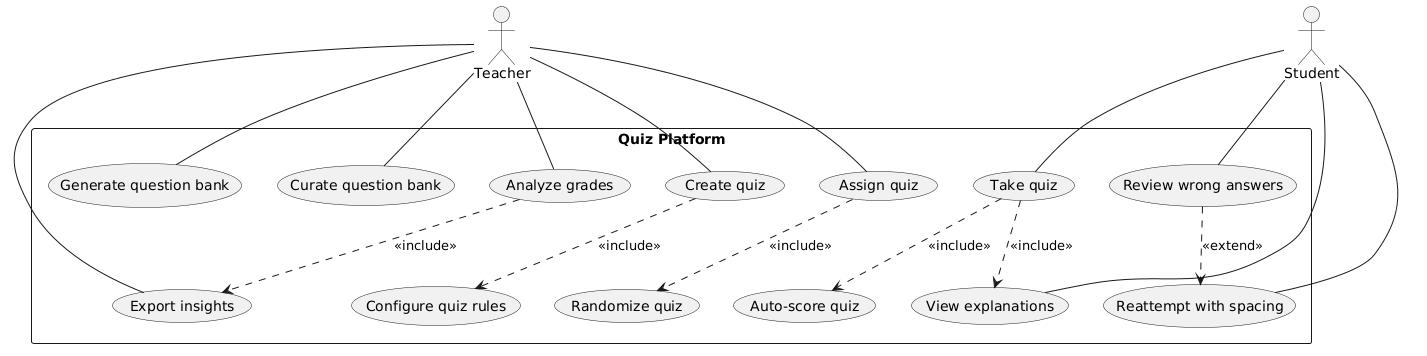

In [7]:
from utils import render_plantuml_diagram

if client and 'user_stories' in globals():
    print("--- Generating PlantUML Use Case Diagram ---")
    prompt = (
        "Create a PlantUML use case diagram for an educational quiz platform.\n\n"
        "Format:\n@startuml\nactor ActorName\n"
        "rectangle \"Quiz Platform\" {\n  usecase \"Verb Noun\" as UC1\n}\n"
        "ActorName -- UC1\n@enduml\n\n"
        "Rules:\n"
        "- Actors outside system boundary (rectangle)\n"
        "- Use cases inside, verb-noun phrases, no numbering\n"
        "- Use -- for associations, ..> for <<include>>/<<extend>>\n"
        "- Extract actors from 'role', use cases from 'goal' fields\n"
        "- Return ONLY valid PlantUML code\n\n"
        f"User Stories: {user_stories}"
    )
    puml = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    # Guard: only save if API returned valid PlantUML code
    if puml and not puml.startswith(("An API error", "APIFREE error", "APIFREE request failed", "Error:")):
        puml = clean_llm_output(puml, language='text')
        print("Generated PlantUML diagram:")
        print(puml)
        os.makedirs('artifacts/diagrams', exist_ok=True)
        with open('artifacts/diagrams/use_case_diagram.puml', 'w') as f:
            f.write(puml)
        print('✅ Saved: artifacts/diagrams/use_case_diagram.puml')
        render_plantuml_diagram(puml, "artifacts/diagrams/use_case_diagram.png")
    else:
        print("API request failed. Please re-run this cell.")
        print("If it still fails, please check your network connection and try re-running multiple times.")
else:
    print("Skipping step because LLM client or user_stories is not available.")

Class Diagram

--- Generating PlantUML Class Diagram ---
Generated PlantUML diagram:
@startuml
class Teacher {
  +teacherId: String
  +name: String
  +email: String
  +createQuiz(title: String): Quiz
  +generateQuestionBank(subject: String, unit: String, knowledgePoints: String[*]): Question[*]
  +publishQuestionBank(version: String): void
  +analyzeResults(filters: String): Result[*]
}

class Student {
  +studentId: String
  +name: String
  +email: String
  +accessibilitySettings: String
  +takeQuiz(quiz: Quiz): Result
  +submitAnswer(question: Question, response: String): Answer
  +reviewWrongAnswers(): Answer[*]
  +scheduleReattemptSession(dateTime: String): void
}

class Quiz {
  +quizId: String
  +title: String
  +subject: String
  +unit: String
  +timerSeconds: int
  +attemptLimit: int
  +questionCount: int
  +typeMix: String
  +difficultyDistribution: String
  +published: boolean
  +assignToStudents(students: Student[*]): void
  +generateRandomizedVariantFor(student: Student): Quiz
  +start(st

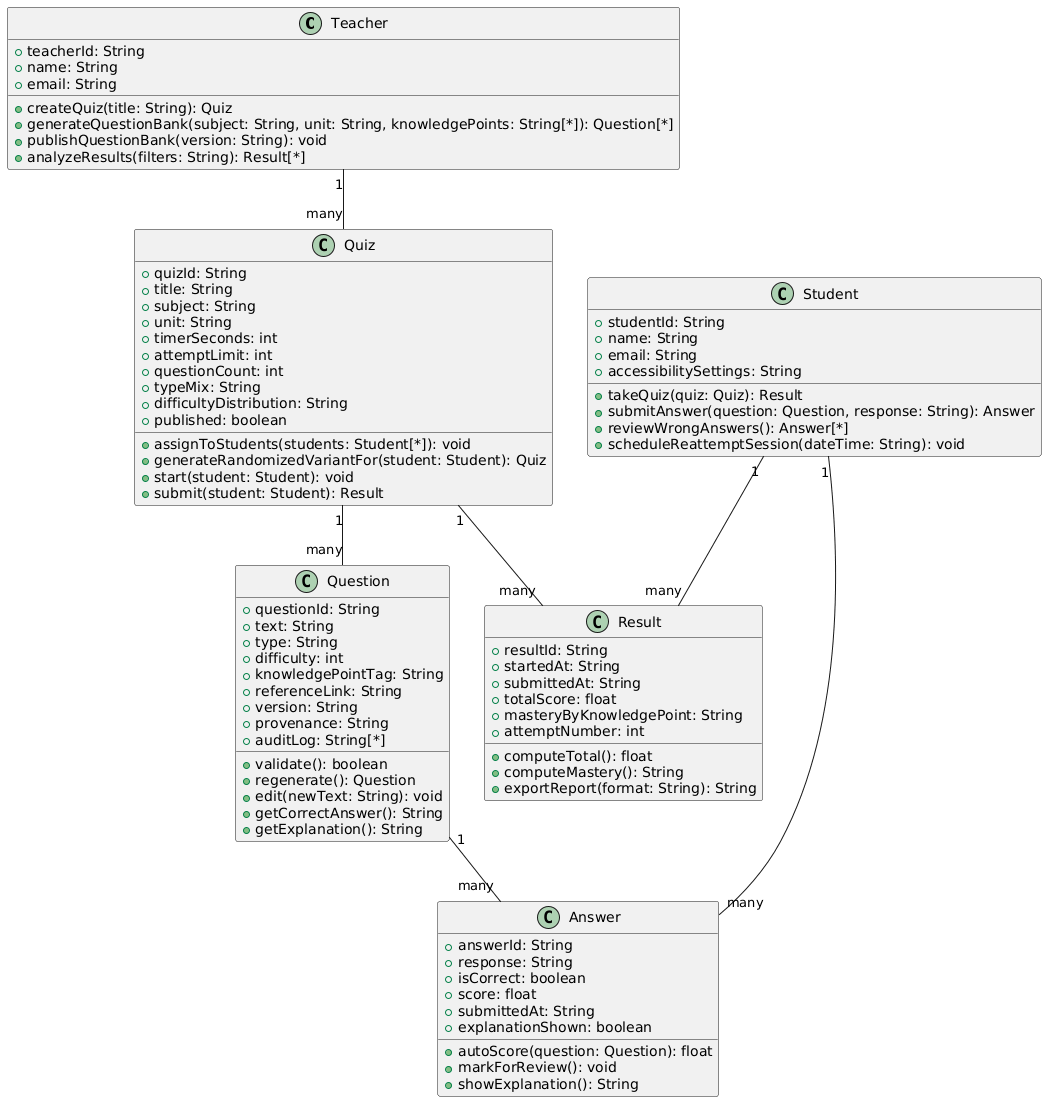

In [8]:
if client and 'user_stories' in globals():
    print("--- Generating PlantUML Class Diagram ---")
    prompt = (
        "Create a PlantUML class diagram for an educational quiz platform.\n\n"
        "Format:\n@startuml\nclass ClassName {\n  +attr: Type\n  +method(): Type\n}\n"
        "ClassName \"1\" -- \"many\" OtherClass\n@enduml\n\n"
        "Rules:\n"
        "- Include: Quiz, Question, Answer, Student, Teacher, Result\n"
        "- Show key attributes and methods per class\n"
        "- Use -- with multiplicities for associations\n"
        "- Return ONLY valid PlantUML code\n\n"
        f"User Stories: {user_stories}"
    )
    puml = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    # Guard: only save if API returned valid PlantUML code
    if puml and not puml.startswith(("An API error", "APIFREE error", "APIFREE request failed", "Error:")):
        puml = clean_llm_output(puml, language='text')
        print("Generated PlantUML diagram:")
        print(puml)
        os.makedirs('artifacts/diagrams', exist_ok=True)
        with open('artifacts/diagrams/class_diagram.puml', 'w') as f:
            f.write(puml)
        print('✅ Saved: artifacts/diagrams/class_diagram.puml')
        render_plantuml_diagram(puml, "artifacts/diagrams/class_diagram.png")
    else:
        print("API request failed. Please re-run this cell.")
        print("If it still fails, please check your network connection and try re-running multiple times.")
else:
    print("Skipping step because LLM client or user_stories is not available.")

Sequence Diagram

--- Generating PlantUML Sequence Diagram ---
Generated PlantUML diagram:
@startuml
actor Student
participant "Quiz API" as API
participant "Scoring Service" as Score
participant "Review Service" as Review

Student -> API: GET /quiz/{quizId}
API --> Student: 200 questions + rules(timer, attempts) + sessionId

loop For each question
  Student -> API: POST /quiz/{quizId}/answer {sessionId, questionId, answer}
  API --> Student: 200 answer saved
end

Student -> API: POST /quiz/{quizId}/submit {sessionId}
API -> Score: POST /score {sessionId}
Score --> API: scores + per-knowledge-point mastery + explanations + references + wrongQuestionIds
API --> Student: 200 results (total, per-question, mastery, explanations, references)

Student -> API: GET /quiz/{quizId}/results?sessionId=...
API --> Student: 200 results detail

Student -> API: GET /quiz/{quizId}/review/wrong?sessionId=...
API -> Review: POST /review-list {studentId, quizId, wrongQuestionIds}
Review --> API: 201 saved
API --> Student: 

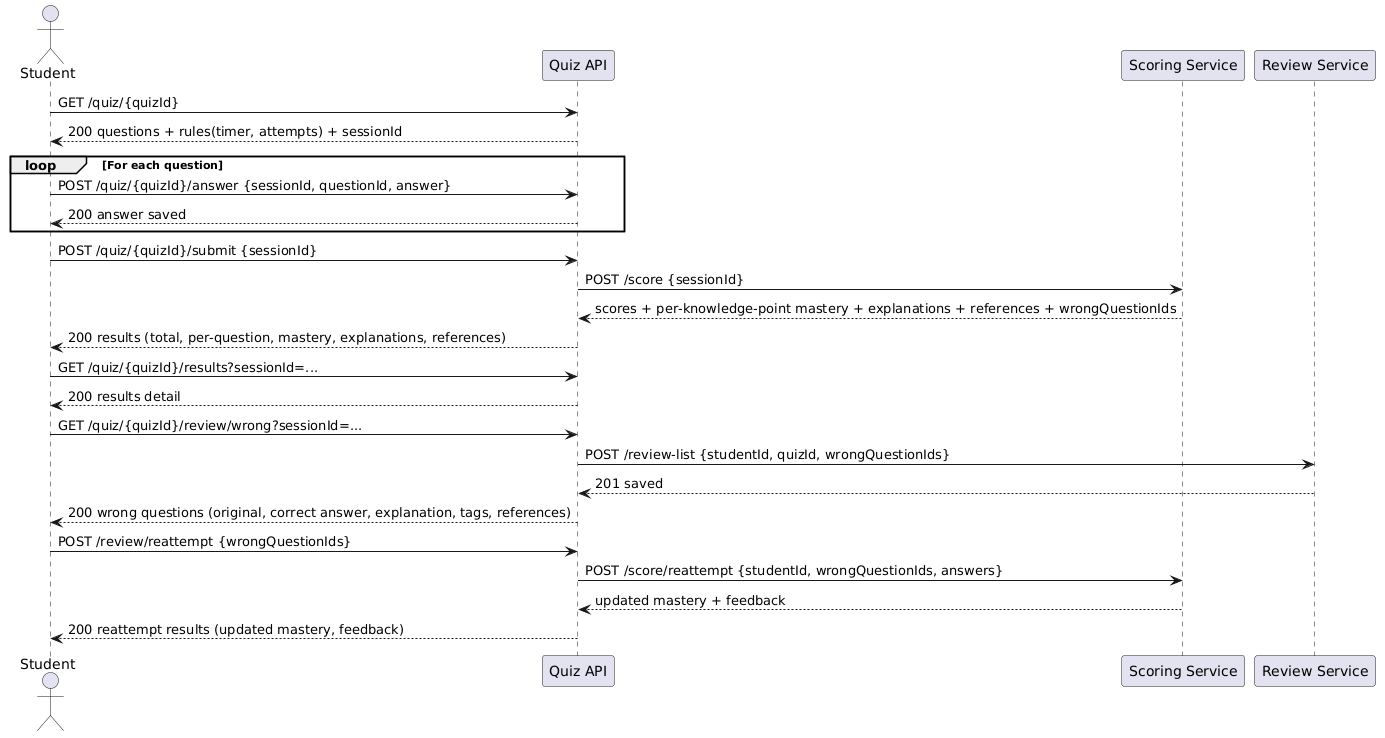

In [9]:
from utils import render_plantuml_diagram

if client and 'user_stories' in globals():
    print("--- Generating PlantUML Sequence Diagram ---")
    prompt = (
        "Create a PlantUML sequence diagram for the 'take quiz' flow.\n\n"
        "Format:\n@startuml\nactor Student\nparticipant \"Quiz API\" as API\n"
        "Student -> API: GET /quiz\nAPI --> Student: questions\n@enduml\n\n"
        "Rules:\n"
        "- Full flow: request quiz → answer → auto-score → view results → review wrong\n"
        "- Use -> for calls, --> for responses\n"
        "- At least 3 participants\n"
        "- Return ONLY valid PlantUML code\n\n"
        f"User Stories: {user_stories}"
    )
    puml = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    # Guard: only save if API returned valid PlantUML code
    if puml and not puml.startswith(("An API error", "APIFREE error", "APIFREE request failed", "Error:")):
        puml = clean_llm_output(puml, language='text')
        print("Generated PlantUML diagram:")
        print(puml)
        os.makedirs('artifacts/diagrams', exist_ok=True)
        with open('artifacts/diagrams/sequence_diagram.puml', 'w') as f:
            f.write(puml)
        print('✅ Saved: artifacts/diagrams/sequence_diagram.puml')
        render_plantuml_diagram(puml, "artifacts/diagrams/sequence_diagram.png")
    else:
        print("API request failed. Please re-run this cell.")
        print("If it still fails, please check your network connection and try re-running multiple times.")
else:
    print("Skipping step because LLM client or user_stories is not available.")

#### 2) AI generated Code

In [10]:
if client and 'user_stories' in globals():
    import json, shutil, re
    print('--- Generating Quiz Platform Flask API (Incremental Build) ---')

    # Parse user stories for endpoint generation
    try:
        stories_data = json.loads(user_stories) if isinstance(user_stories, str) else user_stories
        stories_list = stories_data if isinstance(stories_data, list) else stories_data.get('user_stories', [])
    except:
        print('Error parsing user stories')
        stories_list = []

    # Step 1: Generate base app skeleton
    base_app = get_completion(
        "Create a minimal Flask app skeleton for a quiz platform with: "
        "from flask import Flask, request, jsonify, send_from_directory; "
        "from flask_cors import CORS; import os, random; "
        "app = Flask(__name__); CORS(app); "
        "in-memory storage: question_bank = [<3 sample Python quiz questions>, ...], "
        "quiz_results = []; "
        "Each question in question_bank must be a dict with keys: "
        "subject, question, options (list of strings), answer, explanation. "
        "Add a health check endpoint GET /health that returns {status: ok}. "
        "Do NOT include if __name__ == '__main__' block. Keep under 30 lines.",
        client, model_name, api_provider, temperature=0.3
    )
    # Guard: check base app generation
    if base_app and not base_app.startswith(('An API error', 'APIFREE error', 'APIFREE request failed', 'Error:')):
        base_app = clean_llm_output(base_app, language='python')
        print('✅ Generated base app structure')
    else:
        print("API request failed. Please re-run this cell.")
        print("If it still fails, please check your network connection and try re-running multiple times.")
        base_app = None

    if base_app:
        # Step 2: Generate endpoints for each user story iteratively
        endpoint_assignments = [
            "GET /questions (list all questions) and POST /questions (add a new question)",
            "GET /quiz?count=N (return N random questions) and POST /submit (submit answers for auto-scoring)",
            "GET /stats (return grade statistics) and GET /wrong (return wrong-answer review list)"
        ]
        endpoints_code = []
        for i, story in enumerate(stories_list[:3], 1):
            story_text = f"Role: {story.get('role', '')}, Goal: {story.get('goal', '')}"
            assigned = endpoint_assignments[i - 1] if i <= len(endpoint_assignments) else endpoint_assignments[-1]
            print(f'  Generating endpoint {i}/3: {assigned[:50]}...')

            endpoint_code = get_completion(
                f"Write Flask endpoint functions for a quiz platform. User story: {story_text}. "
                f"Generate ONLY these specific endpoints: {assigned}. "
                f"Use question_bank and quiz_results lists for storage. "
                f"Return only the @app.route decorated function code. "
                f"Do NOT include if __name__ == '__main__' block. Keep under 25 lines. "
                f"Ensure endpoints return JSON with proper status codes.",
                client, model_name, api_provider, temperature=0.3
            )
            # Guard: skip failed endpoint, continue with others
            if endpoint_code and not endpoint_code.startswith(('An API error', 'APIFREE error', 'APIFREE request failed', 'Error:')):
                endpoint_code = clean_llm_output(endpoint_code, language='python')
                endpoints_code.append(f"\n# Endpoint for Story {i}: {story.get('role', 'user')}\n{endpoint_code}")
                print(f'Endpoint {i}/3 generated')
            else:
                print("API request failed. Please re-run this cell.")
                print("If it still fails, please check your network connection and try re-running multiple times.")

        # Step 3: Add static routes + AI-powered /generate endpoint
        static_and_generate_routes = """\nfrom dotenv import load_dotenv
load_dotenv()

# Serve frontend and static files
@app.route('/')
def index():
    return send_from_directory('.', 'index.html')

@app.route('/static/<path:filename>')
def serve_static(filename):
    return send_from_directory('static', filename)

# AI-powered quiz generation endpoint
@app.route('/generate', methods=['POST'])
def generate_quiz():
    \"\"\"Accept a topic, call LLM API to generate quiz questions, add to question_bank.\"\"\"
    data = request.get_json() or {}
    topic = data.get('topic', '').strip()
    count = data.get('count', 5)
    if not topic:
        return jsonify({'error': 'Topic is required'}), 400
    api_key = os.environ.get('APIFREE_API_KEY', '')
    if not api_key:
        return jsonify({'error': 'APIFREE_API_KEY not configured on server'}), 500
    base_url = os.environ.get('APIFREE_API_BASE', 'https://api.apifree.ai')
    headers = {'Authorization': f'Bearer {api_key}', 'Content-Type': 'application/json'}
    prompt = (
        f'Generate {count} multiple-choice quiz questions about: {topic}. '
        f'Return ONLY a JSON array. Each element must have keys: '
        f'subject, question, options (list of 3-4 strings), answer, explanation. '
        f'No markdown, no code fences, just the raw JSON array.'
    )
    payload = {
        'model': 'openai/gpt-4o-mini',
        'messages': [{'role': 'user', 'content': prompt}],
        'max_tokens': 4096,
        'temperature': 0.5,
    }
    try:
        import requests as _req
        resp = _req.post(f'{base_url}/v1/chat/completions', headers=headers, json=payload, timeout=120)
        if not resp.ok:
            return jsonify({'error': f'LLM API error: {resp.status_code}'}), 502
        content = resp.json().get('choices', [{}])[0].get('message', {}).get('content', '')
        # Strip markdown code fences if present
        content = content.strip()
        if content.startswith('```'):
            content = content.split('\\n', 1)[-1].rsplit('```', 1)[0].strip()
        new_questions = json.loads(content)
        if isinstance(new_questions, list):
            question_bank.extend(new_questions)
            return jsonify({'generated': len(new_questions), 'total': len(question_bank), 'questions': new_questions})
        return jsonify({'error': 'LLM did not return a valid list'}), 502
    except Exception as e:
        return jsonify({'error': f'Generation failed: {str(e)}'}), 500
"""

        # Step 4: Concatenate all parts + single if __name__ entry point
        main_py_code = base_app + "\n".join(endpoints_code) + static_and_generate_routes
        # Remove any accidental if __name__ blocks from AI-generated snippets
        parts = main_py_code.split('if __name__')
        if len(parts) > 1:
            main_py_code = parts[0]
        # Deduplicate @app.route definitions (keep first occurrence of each route path)
        route_blocks = re.split(r'(?=@app\.route)', main_py_code)
        base_part = route_blocks[0]
        route_parts = route_blocks[1:]
        seen_paths = set()
        unique_routes = []
        for block in route_parts:
            path_match = re.match(r"@app\.route\(['\"]([^'\"]+)['\"]", block.strip())
            if path_match:
                path = path_match.group(1)
                if path not in seen_paths:
                    seen_paths.add(path)
                    unique_routes.append(block)
                else:
                    print(f'Deduplicated duplicate route: {path}')
            else:
                unique_routes.append(block)
        main_py_code = base_part + ''.join(unique_routes)
        # Append the only execution entry point at the end
        main_py_code += "\n\nif __name__ == '__main__':\n    app.run(host='0.0.0.0', debug=True, port=5005)"

        os.makedirs('artifacts/app/flask/static', exist_ok=True)
        with open('artifacts/app/flask/main.py', 'w') as f:
            f.write(main_py_code)
        print('✅ Saved: artifacts/app/flask/main.py')

        # Write API key into flask .env so Flask/Docker can use it
        flask_env_path = 'artifacts/app/flask/.env'
        api_key_value = os.environ.get('APIFREE_API_KEY', '')
        api_base_value = os.environ.get('APIFREE_API_BASE', 'https://api.apifree.ai')
        with open(flask_env_path, 'w') as f:
            f.write(f'APIFREE_API_KEY={api_key_value}\n')
            f.write(f'APIFREE_API_BASE={api_base_value}\n')
        if api_key_value:
            print(f'Saved: {flask_env_path} (API key loaded from environment)')
        else:
            print(f'Saved: {flask_env_path} but APIFREE_API_KEY is empty')

    # Step 5: AI-generated knowledge mind map image
    print('--- Generating AI Knowledge Mind Map ---')
    img_client, img_model, img_provider = setup_llm_client('qwen/qwen-image-2512')
    if img_client:
        file_path, _ = get_image_generation_completion(
            'An abstract colorful illustration of interconnected knowledge nodes '
            'and learning pathways, using geometric shapes, gradient colors, '
            'flowing curves and dots, modern minimalist style, '
            'purple blue green orange palette, dark background, NO TEXT, NO WORDS, NO LETTERS',
            img_client, img_model, img_provider
        )
        if file_path and os.path.exists(file_path):
            shutil.copy(file_path, 'artifacts/app/flask/static/mindmap.png')
            print('✅ Saved: artifacts/app/flask/static/mindmap.png')

    # Step 6: Generate quiz frontend HTML
    print('--- Generating Quiz Frontend ---')
    html_prompt = (
        "Generate a complete single-page HTML5 quiz platform using Bootstrap 5 CDN.\n\n"
        "SECTIONS (top to bottom):\n"
        "1. Hero: title 'AI Quiz Platform' + subtitle 'Enter a topic, AI generates quiz for you' "
        "   + <img src='static/mindmap.png' style='max-width:400px'>\n"
        "2. Topic Input: ONE text input (placeholder='e.g. Python Basics: variables, loops, functions') "
        "   + number input for question count (default 5, min 1, max 20) "
        "   + button 'Generate Quiz' that POSTs JSON {topic, count} to http://127.0.0.1:5005/generate "
        "   + show loading spinner while generating, then auto-load quiz after success\n"
        "3. Quiz: button 'Start Quiz' fetches GET http://127.0.0.1:5005/quiz?count=5, "
        "   renders questions as radio-button form, submit via POST http://127.0.0.1:5005/submit\n"
        "4. Results: shows score and breakdown after submission\n"
        "5. Wrong Review: button fetches GET http://127.0.0.1:5005/wrong\n"
        "6. Stats: button fetches GET http://127.0.0.1:5005/stats\n\n"
        "RULES:\n"
        "- All CSS in <style>, JS in <script>, use Fetch API\n"
        "- Submit payload format: {answers: [{question_id: N, selected: 'choice'}]}\n"
        "- Display API errors clearly to the user\n"
        "- Output ONLY valid HTML document\n"
        "- Dark theme (#1a1a2e background) BUT all text must be BRIGHT and READABLE: "
        "use #e0e0e0 for body text, #ffffff for headings, #bb86fc for accents/highlights. "
        "Input fields: dark bg (#2d2d44) with LIGHT placeholder text (#aaaaaa). "
        "Buttons: vibrant purple (#7c4dff) with white text.\n"
        "- NO 'Add Question' form with multiple fields. The ONLY input is the topic text."
    )
    html_code = get_completion(
        html_prompt, client, model_name, api_provider, temperature=0.4
    )
    # Guard: only save if HTML generation succeeded
    if html_code and not html_code.startswith(('An API error', 'APIFREE error', 'APIFREE request failed', 'Error:')):
        html_code = clean_llm_output(html_code, language='html')
        with open('artifacts/app/flask/index.html', 'w') as f:
            f.write(html_code)
        print('✅ Saved: artifacts/app/flask/index.html')
    else:
        print("API request failed. Please re-run this cell.")
        print("If it still fails, please check your network connection and try re-running multiple times.")


    # Step 7: Generate test script for CI/CD
    test_code = """import requests, sys
BASE = "http://127.0.0.1:5005"

def test_health():
    r = requests.get(f"{BASE}/health")
    assert r.status_code == 200 and r.json()["status"] == "ok"

def test_add_question():
    r = requests.post(f"{BASE}/questions", json={
        "subject": "Python", "question": "What is a variable?",
        "options": ["A container", "A function", "A class"],
        "answer": "A container", "explanation": "Variables store values."
    })
    assert r.status_code == 201

def test_get_quiz():
    test_add_question()
    r = requests.get(f"{BASE}/quiz?count=1")
    assert r.status_code == 200 and len(r.json()["questions"]) >= 1

if __name__ == "__main__":
    for fn in [test_health, test_add_question, test_get_quiz]:
        try:
            fn(); print(f"✅ {fn.__name__} passed")
        except Exception as e:
            print(f" {fn.__name__} failed: {e}"); sys.exit(1)
"""
    with open('artifacts/app/flask/tests.py', 'w') as f:
        f.write(test_code)
    print('✅ Saved: artifacts/app/flask/tests.py')

    # Step 8: Generate README.md with integration instructions
    readme_content = get_completion(
        'Write a README.md (under 250 words) for a Flask quiz platform API with HTML frontend. '
        'Include: title, description, setup (pip install flask flask-cors), run command (python main.py), '
        'how to access the app (http://127.0.0.1:5005), and 2 curl examples for POST /questions and GET /quiz endpoints.',
        client, model_name, api_provider, temperature=0.3
    )
    if readme_content and not readme_content.startswith(('An API error', 'APIFREE error', 'APIFREE request failed', 'Error:')):
        readme_content = clean_llm_output(readme_content, language='markdown')
        with open('artifacts/app/flask/README.md', 'w') as f:
            f.write(readme_content)
        print('✅ Saved: artifacts/app/flask/README.md')
    else:
        print("API request failed. Please re-run this cell.")
        print("If it still fails, please check your network connection and try re-running multiple times.")

    print('\n✅ Quiz Platform generated: API + Frontend + AI Image + Tests + README')
else:
    print('Skipping step because LLM client or user_stories is not available.')

--- Generating Quiz Platform Flask API (Incremental Build) ---
✅ Generated base app structure
  Generating endpoint 1/3: GET /questions (list all questions) and POST /ques...
Endpoint 1/3 generated
  Generating endpoint 2/3: GET /quiz?count=N (return N random questions) and ...
Endpoint 2/3 generated
  Generating endpoint 3/3: GET /stats (return grade statistics) and GET /wron...
Endpoint 3/3 generated
Deduplicated duplicate route: /questions
✅ Saved: artifacts/app/flask/main.py
Saved: artifacts/app/flask/.env (API key loaded from environment)
--- Generating AI Knowledge Mind Map ---
✅ LLM Client configured: Using 'apifree' with model 'qwen/qwen-image-2512'
Generating image... This may take a moment.


⏳ Generating image...

Still generating image... (poll 5/60)
✅ Image generated in 37.87 seconds.
✅ Image saved to: artifacts\artifacts\screens\image_1780290301723.png
✅ Saved: artifacts/app/flask/static/mindmap.png
--- Generating Quiz Frontend ---
✅ Saved: artifacts/app/flask/index.html
✅ Saved: artifacts/app/flask/tests.py
✅ Saved: artifacts/app/flask/README.md

✅ Quiz Platform generated: API + Frontend + AI Image + Tests + README


#### 3) AI generated requirements.txt

In [ ]:
if client and os.path.exists('artifacts/app/flask/main.py'):
    print('--- Generating requirements.txt ---')
    
    # Read the app code
    with open('artifacts/app/flask/main.py', 'r') as f:
        app_code = f.read()
    
    # Extract import statements from the beginning of the file
    import_lines = []
    for line in app_code.split('\n'):
        stripped = line.strip()
        if stripped.startswith('import ') or stripped.startswith('from '):
            import_lines.append(stripped)
        elif stripped and not stripped.startswith('#'):
            break  # Stop at first non-import, non-comment line
    
    imports_text = '\n'.join(import_lines)
    print(f"  Found {len(import_lines)} import statement(s)")
    
    # Generate requirements based on imports with version pinning
    requirements = get_completion(
        f"Based on these Python import statements, generate a requirements.txt.\n"
        f"Rules:\n"
        f"1. One package per line, format: package==version\n"
        f"2. Remove duplicates and standard library modules (os, json, random, etc.)\n"
        f"3. Map imports to correct PyPI names: 'from dotenv import load_dotenv' → 'python-dotenv' (NOT 'dotenv')\n"
        f"4. These packages MUST all appear in the output with these exact versions:\n"
        f"   flask==2.3.3, flask-cors==4.0.0, requests==2.31.0, werkzeug==3.1.5, python-dotenv==1.0.0\n"
        f"5. Output ONLY the requirements.txt content, no explanation\n"
        f"Import statements:\n{imports_text}",
        client, model_name, api_provider, temperature=0.3
    )

    # Guard: check if API returned valid content
    if requirements and not requirements.startswith(('An API error', 'APIFREE error', 'APIFREE request failed', 'Error:')):
        requirements = clean_llm_output(requirements, language='text')
        req_lines = [line.strip() for line in requirements.split('\n')]
        req_lines = [line for line in req_lines if line and not line.startswith('#')]
        req_list = sorted(set(req_lines))

        # Safety net: ensure critical packages are present
        REQUIRED_PACKAGES = {
            'flask': 'flask==2.3.3',
            'flask-cors': 'flask-cors==4.0.0',
            'requests': 'requests==2.31.0',
            'werkzeug': 'werkzeug==3.1.5',
            'python-dotenv': 'python-dotenv==1.0.0',
        }
        existing_pkgs = set()
        for line in req_list:
            pkg_name = line.split('==')[0].split('>=')[0].split('<=')[0].strip().lower()
            existing_pkgs.add(pkg_name)
        
        missing = [pkg_line for pkg_name, pkg_line in REQUIRED_PACKAGES.items()
                   if pkg_name.lower() not in existing_pkgs]
        if missing:
            print(f" Missing packages detected, adding: {missing}")
            req_list = sorted(set(req_list + missing))

        with open('artifacts/app/flask/requirements.txt', 'w') as f:
            f.write('\n'.join(req_list))
        print(f'✅ Saved: artifacts/app/flask/requirements.txt ({len(req_list)} packages)')
        print(f"  Packages: {', '.join(req_list)}")
    else:
        print("API request failed. Please re-run this cell.")
        print("If it still fails, please check your network connection and try re-running multiple times.")
else:
    print('Skipping step because Flask app is not available.')

--- Generating requirements.txt ---
  Found 3 import statement(s)
✅ Saved: artifacts/app/flask/requirements.txt (2 packages)
  Packages: flask-cors==4.0.0, flask==2.3.3


## Phase 3: Operation
AI oversees deployments, infrastructure-as-code, monitoring, and ongoing operations based on the accumulated project context. Here we package the quiz platform application into a Docker container for easy deployment and reproducibility.

In [14]:
import os

dockerfile_content = """FROM python:3.10-slim
WORKDIR /app
COPY flask/requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt
COPY flask/ .
EXPOSE 5005
ENV FLASK_APP=main.py
ENV FLASK_ENV=production
CMD ["python", "main.py"]
"""

dockerignore_content = """__pycache__
*.pyc
.git
.vscode
.pytest_cache
"""

docker_compose_content = """version: '3.8'
services:
  quiz-app:
    build:
      context: .
      dockerfile: docker/Dockerfile
    container_name: quiz-platform
    ports:
      - "5005:5005"
    environment:
      - FLASK_ENV=production
    volumes:
      - ./flask:/app
    restart: unless-stopped
"""

if os.path.exists('artifacts/app/flask/main.py'):
    print("--- Generating Docker Configuration ---")
    os.makedirs('artifacts/app/docker', exist_ok=True)
    with open('artifacts/app/docker/Dockerfile', 'w') as f:
        f.write(dockerfile_content)
    print('✅ Saved: artifacts/app/docker/Dockerfile')
    with open('artifacts/app/docker/.dockerignore', 'w') as f:
        f.write(dockerignore_content)
    print('✅ Saved: artifacts/app/docker/.dockerignore')
    with open('artifacts/app/docker-compose.yml', 'w') as f:
        f.write(docker_compose_content)
    print('✅ Saved: artifacts/app/docker-compose.yml')
    print("""
📦 Docker Build & Run (from artifacts/app directory):

1. cd to ./artifacts/app
2. (Need to start Docker Desktop) Run "docker build -t quiz-platform:latest -f docker/Dockerfile ."
3. Run "docker run -p 5005:5005 quiz-platform:latest"
   OR: docker-compose up --build
4. Open http://127.0.0.1:5005
5. Stop: docker stop quiz-platform
6. Clean: docker-compose down
""")
    print("✅ Docker setup complete!")
else:
    print(" Flask app not found. Run code generation cell first.")

--- Generating Docker Configuration ---
✅ Saved: artifacts/app/docker/Dockerfile
✅ Saved: artifacts/app/docker/.dockerignore
✅ Saved: artifacts/app/docker-compose.yml

📦 Docker Build & Run (from artifacts/app directory):

1. cd to ./artifacts/app
2. (Need to start Docker Desktop) Run "docker build -t quiz-platform:latest -f docker/Dockerfile ."
3. Run "docker run -p 5005:5005 quiz-platform:latest"
   OR: docker-compose up --build
4. Open http://127.0.0.1:5005
5. Stop: docker stop quiz-platform
6. Clean: docker-compose down

✅ Docker setup complete!
